In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
AWTIP_Stommel_1.py

Perfect-model probability pathway for the Cessi (1994) quadratic-closure
AMOC box model with slowly increasing freshwater forcing p(t):

    OSSE truth -> synthetic observations -> particle filter posterior
    -> TAMS conditioned on the posterior -> P10(t) warning probability.

    dx/dt = -alpha*(x-1) - x * Q(x,y)
    dy/dt =  p(t) - y * Q(x,y)
    Q(x,y)= 1 + mu^2*(x-y)^2
    p(t)  = p0 + pdot*t

The warning/collapse variable is z = x - y. The event is z <= zCrit.

"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use("Agg")  # headless-safe; figures are saved to PNG regardless
import matplotlib.pyplot as plt

# __file__ is undefined when this script is run inside a Jupyter cell
# (as opposed to `python AWTIP_Stommel_1.py` from a terminal), so fall
# back to the current working directory in that case.
try:
    _SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    _SCRIPT_DIR = Path.cwd()


# =============================================================================
#                               PARAMETERS
# =============================================================================

@dataclass
class Params:
    # Cessi (1994)-style nondimensional parameters
    alpha: float = 100.0
    mu2: float = 4.0      # mu^2 in Q = 1 + mu^2*(x-y)^2
    p0: float = 0.9       # initial freshwater forcing
    pdot: float = 0.002   # slow increase of freshwater forcing per model year
    sigx: float = 0.020   # stochastic forcing in x equation
    sigy: float = 0.020   # stochastic forcing in y equation

    # Numerical integration
    dt: float = 0.01      # model time step, interpreted as years


# =============================================================================
#                          CORE MODEL FUNCTIONS
# =============================================================================

def z_amoc(x, y):
    """AMOC proxy / density contrast in the Cessi model."""
    return x - y


def exchange_Q(x, y, par: Params):
    """Cessi (1994) familiar quadratic exchange closure."""
    z = z_amoc(x, y)
    return 1.0 + par.mu2 * z ** 2


def p_forcing(par: Params, t):
    """Slowly increasing freshwater forcing."""
    return par.p0 + par.pdot * t


def drift_rhs(state, par: Params, t):
    """
    Correct Cessi (1994) quadratic model with time-dependent freshwater p(t):
        dx/dt = -alpha*(x-1) - x*[1+mu^2*(x-y)^2]
        dy/dt =  p(t)        - y*[1+mu^2*(x-y)^2]
    """
    x, y = state[0], state[1]
    Q = exchange_Q(x, y, par)
    p = p_forcing(par, t)
    f = np.empty(2)
    f[0] = -par.alpha * (x - 1.0) - x * Q
    f[1] = p - y * Q
    return f


def em_step(x, par: Params, t, rng: np.random.Generator):
    """One Euler-Maruyama step."""
    f = drift_rhs(x, par, t)
    noise = np.sqrt(par.dt) * np.array([par.sigx, par.sigy]) * rng.standard_normal(2)
    return x + par.dt * f + noise


def propagate_state(x, par: Params, n_sub_steps, t_start, rng: np.random.Generator):
    for n in range(n_sub_steps):
        t = t_start + n * par.dt
        x = em_step(x, par, t, rng)
    return x


def simulate_path(x0, par: Params, n_steps, t_start, rng: np.random.Generator):
    Xv = np.zeros(n_steps + 1)
    Yv = np.zeros(n_steps + 1)
    zv = np.zeros(n_steps + 1)
    pv = np.zeros(n_steps + 1)

    Xv[0], Yv[0] = x0[0], x0[1]
    zv[0] = z_amoc(Xv[0], Yv[0])
    pv[0] = p_forcing(par, t_start)

    x = np.array(x0, dtype=float)
    for n in range(1, n_steps + 1):
        t = t_start + (n - 1) * par.dt
        x = em_step(x, par, t, rng)
        Xv[n], Yv[n] = x[0], x[1]
        zv[n] = z_amoc(x[0], x[1])
        pv[n] = p_forcing(par, t_start + n * par.dt)

    return Xv, Yv, zv, pv


def jacobian_rhs(state, par: Params, t):
    x, y = state[0], state[1]
    z = x - y
    Q = 1.0 + par.mu2 * z ** 2
    dQdx = 2.0 * par.mu2 * z
    dQdy = -2.0 * par.mu2 * z

    # f1 = -alpha*(x-1) - x*Q
    # f2 = p(t) - y*Q
    J = np.zeros((2, 2))
    J[0, 0] = -par.alpha - Q - x * dQdx
    J[0, 1] = -x * dQdy
    J[1, 0] = -y * dQdx
    J[1, 1] = -Q - y * dQdy
    return J


def deterministic_equilibrium(par: Params, x0, t):
    """Newton iteration for deterministic equilibrium at fixed p(t)."""
    x = np.array(x0, dtype=float)
    for _ in range(100):
        f = drift_rhs(x, par, t)
        J = jacobian_rhs(x, par, t)
        dx = -np.linalg.solve(J, f)
        x = x + 0.5 * dx
        if np.sqrt(np.sum(dx ** 2)) < 1e-11:
            break
    return x


def obs_operator(x, par: Params):
    return z_amoc(x[0], x[1])


def obs_likelihood_log(y, yhat, sig):
    r = y - yhat
    return -0.5 * (r / sig) ** 2 - np.log(sig * np.sqrt(2 * np.pi))



In [ ]:
# =============================================================================
#                            PARTICLE FILTER UTILS
# =============================================================================

def systematic_resample(w, rng: np.random.Generator):
    N = len(w)
    edges = np.minimum(np.concatenate(([0.0], np.cumsum(w))), 1.0)
    edges[-1] = 1.0
    u1 = rng.random() / N
    u = u1 + np.arange(N) / N
    idx = np.zeros(N, dtype=int)
    j = 0
    for i in range(N):
        while u[i] > edges[j + 1]:
            j += 1
        idx[i] = j
    return idx


def sample_discrete(w, M, rng: np.random.Generator):
    w = w / np.sum(w)
    cw = np.cumsum(w)
    idx = np.zeros(M, dtype=int)
    for m in range(M):
        r = rng.random()
        idx[m] = np.searchsorted(cw, r, side="left")
    return idx


In [ ]:
# =============================================================================
#                                   TAMS
# =============================================================================

def simulate_score_path(x0, par: Params, n_steps, zCrit, t_start, rng: np.random.Generator):
    Xv = np.zeros(n_steps + 1)
    Yv = np.zeros(n_steps + 1)
    x = np.array(x0, dtype=float)
    Xv[0], Yv[0] = x[0], x[1]
    xi0 = zCrit - z_amoc(x[0], x[1])
    max_xi = xi0
    hit = xi0 >= 0

    for n in range(1, n_steps + 1):
        t = t_start + (n - 1) * par.dt
        x = em_step(x, par, t, rng)
        Xv[n], Yv[n] = x[0], x[1]
        xi = zCrit - z_amoc(x[0], x[1])
        max_xi = max(max_xi, xi)
        hit = hit or (xi >= 0)

    return Xv, Yv, max_xi, hit


def tams_transition_probability(x0, par: Params, Hsteps, zCrit, Nrep, maxKills,
                                 t_start, rng: np.random.Generator):
    """
    TAMS estimate of P(min_{0..H} z <= zCrit | x0, p(t_start+s)).

    Reaction coordinate:
        xi = zCrit - z. Event when max xi >= 0.
    """
    Xpath = np.zeros((Nrep, Hsteps + 1))
    Ypath = np.zeros((Nrep, Hsteps + 1))
    score = np.zeros(Nrep)
    hit = np.zeros(Nrep, dtype=bool)

    for r in range(Nrep):
        Xpath[r, :], Ypath[r, :], score[r], hit[r] = simulate_score_path(
            x0, par, Hsteps, zCrit, t_start, rng
        )

    logW = 0.0
    kills = 0
    all_idx = np.arange(Nrep)

    while kills < maxKills:
        iworst = int(np.argmin(score))
        smin = score[iworst]

        # If the worst score already exceeds zero, all replicas reached the event.
        if smin >= 0:
            break

        survivors = all_idx[all_idx != iworst]
        good = survivors[score[survivors] > smin]
        if good.size == 0:
            break
        ipar = good[rng.integers(0, good.size)]

        xiParent = zCrit - (Xpath[ipar, :] - Ypath[ipar, :])
        tau_candidates = np.nonzero(xiParent >= smin)[0]
        if tau_candidates.size == 0:
            break
        tau = int(tau_candidates[0])

        # One-kill splitting weight update.
        logW += np.log(1.0 - 1.0 / Nrep)

        # Clone prefix and resimulate the tail independently.
        Xnew = np.zeros(Hsteps + 1)
        Ynew = np.zeros(Hsteps + 1)
        Xnew[: tau + 1] = Xpath[ipar, : tau + 1]
        Ynew[: tau + 1] = Ypath[ipar, : tau + 1]

        x = np.array([Xnew[tau], Ynew[tau]])
        prefix_xi = zCrit - (Xnew[: tau + 1] - Ynew[: tau + 1])
        max_xi = np.max(prefix_xi)
        was_hit = bool(np.any(prefix_xi >= 0))

        for n in range(tau, Hsteps):
            t = t_start + (n - 1) * par.dt
            x = em_step(x, par, t, rng)
            Xnew[n + 1] = x[0]
            Ynew[n + 1] = x[1]
            xi = zCrit - z_amoc(x[0], x[1])
            if xi > max_xi:
                max_xi = xi
            if xi >= 0:
                was_hit = True

        Xpath[iworst, :] = Xnew
        Ypath[iworst, :] = Ynew
        score[iworst] = max_xi
        hit[iworst] = was_hit

        kills += 1

    p = np.exp(logW) * np.mean(hit)
    return float(np.clip(p, 0.0, 1.0))

def direct_mc_transition_probability(X, w, par: Params, Hsteps, zCrit, Nmc,
                                      t_start, rng: np.random.Generator):
    """
    Plain-Monte-Carlo cross-check of P(min_{0..H} z <= zCrit) for the
    posterior ensemble (X, w) at time t_start: draw Nmc initial conditions
    from the posterior, forward-integrate each with Euler-Maruyama only
    (no splitting/cloning), and count first-passage crossings of zCrit.
    Unbiased but with plain Monte Carlo (1/sqrt(Nmc)) error. This poses as an
    independent check on the TAMS estimate.

    Also returns the raw hit count. This matters because when n_hits is 0
    (or very small) the reported standard error collapses toward zero even
    though the estimate carries almost no information: p_hat=0, se=0 means
    "the event was never observed in Nmc tries", not "the probability has
    been confirmed to be zero". Anywhere the true probability is below
    roughly 1/Nmc, plain MC cannot distinguish "zero" from "small but
    nonzero"; precisely the regime TAMS exists to resolve.
    """
    idx = sample_discrete(w, Nmc, rng)
    hits = np.zeros(Nmc, dtype=bool)
    for m in range(Nmc):
        x0 = X[:, idx[m]]
        _, _, _, hits[m] = simulate_score_path(x0, par, Hsteps, zCrit, t_start, rng)
    n_hits = int(np.sum(hits))
    p_hat = n_hits / Nmc
    se = np.sqrt(p_hat * (1.0 - p_hat) / Nmc)  # binomial standard error
    return float(p_hat), float(se), n_hits


In [ ]:
# =============================================================================
#                              PLOTTING HELPERS
# =============================================================================

def fill_between_valid(ax, x, y1, y2, color, alpha=0.35, label=None):
    x = np.asarray(x, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    y2 = np.asarray(y2, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y1) & np.isfinite(y2)
    if not np.any(valid):
        return
    ax.fill_between(x[valid], y1[valid], y2[valid], color=color, alpha=alpha,
                     linewidth=0, zorder=0, label=label)


def reliability_curve(p, E, bins):
    p = np.asarray(p, dtype=float)
    E = np.asarray(E, dtype=float)
    nb = len(bins) - 1
    bin_mid = np.full(nb, np.nan)
    obs_freq = np.full(nb, np.nan)
    bin_count = np.zeros(nb, dtype=int)

    for b in range(nb):
        if b < nb - 1:
            idx = (p >= bins[b]) & (p < bins[b + 1])
        else:
            idx = (p >= bins[b]) & (p <= bins[b + 1])
        bin_count[b] = np.sum(idx)
        if bin_count[b] > 0:
            bin_mid[b] = np.mean(p[idx])
            obs_freq[b] = np.mean(E[idx])
        else:
            bin_mid[b] = 0.5 * (bins[b] + bins[b + 1])
            obs_freq[b] = np.nan

    return bin_mid, obs_freq, bin_count


def save_all_open_figures(figs, prefix, out_dir: Path):
    for ii, fig in enumerate(figs, start=1):
        fname = out_dir / f"{prefix}_fig{ii:02d}.png"
        fig.savefig(fname, dpi=200, bbox_inches="tight", facecolor="w")
        print(f"Saved figure: {fname}")


In [ ]:
# =============================================================================
#                                   MAIN
# =============================================================================

def main():
    rng = np.random.default_rng(12)

    '''
    Separate stream for the Fig. 3 diagnostics (direct-MC cross-check and
    repeated-TAMS confidence bands). These draw a huge number of random
    values per call, and if they shared `rng` with the main PF/TAMS loop,
    running them would shift every downstream draw -- changing the
    particle filter's actual trajectory depending on Ndirect_mc or
    R_tams_repeats. A dedicated stream keeps the main run reproducible
    regardless of what the diagnostics do.
    '''

    rng_diag = np.random.default_rng(2024)
    out_dir = Path("/content/drive/MyDrive/Paper")
    out_dir.mkdir(parents=True, exist_ok=True)

    # Global plot styling (mirrors the MATLAB defaultLine/Axes/Text settings).
    plt.rcParams.update({
        "lines.linewidth": 2.5,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "font.size": 16,
        "legend.fontsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    })

    # ----------------------- USER PARAMETERS ------------------------------
    par = Params()

    obs_dt = 1.0      # annual observations
    Tend = 70.0       # OSSE length
    H = 10.0          # 10-year warning horizon

    # Collapse threshold in z=x-y. Increase zCrit if P10 remains too small;
    # decrease it if nearly every forecast is close to one.
    zCrit = 0.14

    # Observation model. Here y_obs = z(x,y) + Gaussian noise.
    obs_sigma_z = 0.025

    # Particle filter
    Np = 500
    Neff_frac = 0.5
    init_spread = np.array([0.03, 0.03])

    # TAMS settings. TAMS is run from a resampled subset of posterior particles.
    Npost_for_TAMS = 25
    Ntams = 90
    maxKills = 2500

    # Direct-MC cross-check (Fig. 3 extension): plain forward EM, no
    # splitting, batch size at each diagnostic snapshot only. Larger Nmc
    # lowers the resolution floor (~1/sqrt(Nmc)) below which plain MC
    # can't tell "zero" from "small but nonzero" -- 4e3 -> ~1.6% floor,
    # 2e5 -> ~0.22%. Still cheap: Stommel-Cessi is 2D with dt=0.01.
    Ndirect_mc = 200_000

    # TAMS confidence bands (Fig. 4 extension): number of independent
    # repeats of the posterior-conditioned TAMS estimate at each
    # diagnostic snapshot, used to quantify the TAMS estimator's own
    # Monte Carlo spread (as opposed to across-particle spread).
    R_tams_repeats = 8

    # Compute P10 every risk_stride observations. Set to 1 for every annual obs.
    risk_stride = 1

    # ----------------------- TIME GRIDS -----------------------------------
    nSteps = round(Tend / par.dt)
    obs_step = round(obs_dt / par.dt)
    Hsteps = round(H / par.dt)
    obs_ind = np.arange(0, nSteps + 1, obs_step)  # 0-based indices (MATLAB obs_ind is 1-based)
    obs_time = obs_ind * par.dt
    nObs = len(obs_ind)

    # ----------------------- TRUTH AND OBSERVATIONS ------------------------
    xEq = deterministic_equilibrium(par, np.array([0.42, 0.16]), 0.0)
    x0_true = xEq + np.array([0.01, -0.01])

    Xtrue, Ytrue, ztrue, ptrue = simulate_path(x0_true, par, nSteps, 0.0, rng)

    yObs = np.full(nObs, np.nan)
    for k in range(nObs):
        ii = obs_ind[k]
        yObs[k] = ztrue[ii] + obs_sigma_z * rng.standard_normal()

    # ----------------------- PARTICLE FILTER -------------------------------
    X = np.tile(xEq.reshape(2, 1), (1, Np)) + init_spread.reshape(2, 1) * rng.standard_normal((2, Np))
    w = np.ones(Np) / Np

    zMean = np.full(nObs, np.nan)
    zStd = np.full(nObs, np.nan)
    Neff = np.full(nObs, np.nan)
    P10 = np.full(nObs, np.nan)
    P10lo = np.full(nObs, np.nan)
    P10hi = np.full(nObs, np.nan)

    diag_times_years = np.array([5, 20, 40, 50])
    diag_idx = np.array([int(np.argmin(np.abs(obs_time - t))) for t in diag_times_years])
    diag = {
        "count": 0,
        "time": [],
        "zParticles": [],
        "wParticles": [],
        "pTamsParticles": [],
        "xParticles": [],
        "pDirectMC": [],
        "pDirectMC_se": [],
        "pDirectMC_nhits": [],
        "pTamsRepeats": [],
    }

    print("Running particle filter + posterior-conditioned TAMS with Cessi p(t) ramp...")

    for k in range(nObs):
        tNow = obs_time[k]

        # Forecast particles from previous obs time to current obs time.
        if k > 0:
            tStart = obs_time[k - 1]
            for i in range(Np):
                X[:, i] = propagate_state(X[:, i], par, obs_step, tStart, rng)

        # Analysis weight update using z observation.
        logL = np.zeros(Np)
        for i in range(Np):
            yhat = obs_operator(X[:, i], par)
            logL[i] = obs_likelihood_log(yObs[k], yhat, obs_sigma_z)

        # Stable weight update.
        logw = np.log(w + np.finfo(float).tiny) + logL
        logw = logw - np.max(logw)
        w = np.exp(logw)
        w = w / np.sum(w)

        Neff[k] = 1.0 / np.sum(w ** 2)

        # Diagnostics of posterior z.
        zPart = z_amoc(X[0, :], X[1, :])
        zMean[k] = np.sum(w * zPart)
        zStd[k] = np.sqrt(np.sum(w * (zPart - zMean[k]) ** 2))

        # Resample if degeneracy.
        if Neff[k] < Neff_frac * Np:
            idx = systematic_resample(w, rng)
            X = X[:, idx]
            w = np.ones(Np) / Np

        # Posterior-conditioned TAMS risk.
        if (k % risk_stride) == 0:
            postIdx = sample_discrete(w, Npost_for_TAMS, rng)
            p_i = np.zeros(Npost_for_TAMS)

            for j in range(Npost_for_TAMS):
                xinit = X[:, postIdx[j]]
                p_i[j] = tams_transition_probability(
                    xinit, par, Hsteps, zCrit, Ntams, maxKills, tNow, rng
                )

            # Because postIdx is sampled from posterior weights, this estimates
            # int p10(x,t) p(x|y_{1:t}) dx.
            P10[k] = np.mean(p_i)

            # Save intermediate diagnostic objects at selected times.
            if k in diag_idx:
                diag["count"] += 1
                diag["time"].append(obs_time[k])
                diag["zParticles"].append(zPart.copy())
                diag["wParticles"].append(w.copy())
                diag["pTamsParticles"].append(p_i.copy())
                diag["xParticles"].append(X.copy())

                # --- Monte Carlo cross-check: plain EM, no splitting ---
                # rng_diag, not rng -- keeps this diagnostic from perturbing
                # the main particle filter's random stream.

                p_direct, se_direct, n_hits_direct = direct_mc_transition_probability(
                    X, w, par, Hsteps, zCrit, Ndirect_mc, tNow, rng_diag
                )

                diag["pDirectMC"].append(p_direct)
                diag["pDirectMC_se"].append(se_direct)
                diag["pDirectMC_nhits"].append(n_hits_direct)

                if n_hits_direct < 10:
                    print(f"    [snapshot t={tNow:5.1f}] WARNING: direct MC saw only "
                          f"{n_hits_direct} hit(s) out of {Ndirect_mc} trajectories -- "
                          f"p_hat={p_direct:.2e} is at/below the reliable MC floor "
                          f"(~1/Nmc={1.0/Ndirect_mc:.1e}). Treat this snapshot as "
                          f"'MC does not contradict TAMS', not a precise confirmation.")

                # --- Repeated TAMS estimate: confidence band on P_10 ---
                # Same reason: rng_diag, not rng.
                p_i_repeats = np.zeros(R_tams_repeats)
                for rr in range(R_tams_repeats):
                    postIdx_rr = sample_discrete(w, Npost_for_TAMS, rng_diag)
                    p_i_rr = np.zeros(Npost_for_TAMS)
                    for j in range(Npost_for_TAMS):
                        xinit_rr = X[:, postIdx_rr[j]]
                        p_i_rr[j] = tams_transition_probability(
                            xinit_rr, par, Hsteps, zCrit, Ntams, maxKills, tNow, rng_diag
                        )
                    p_i_repeats[rr] = np.mean(p_i_rr)
                diag["pTamsRepeats"].append(p_i_repeats.copy())

                print(f"    [snapshot t={tNow:5.1f}] direct MC P10={p_direct:.4f} "
                      f"+/- {se_direct:.4f} (Nmc={Ndirect_mc})  |  "
                      f"TAMS repeats mean={np.mean(p_i_repeats):.4f} "
                      f"std={np.std(p_i_repeats, ddof=1):.4f} (R={R_tams_repeats})")

            if Npost_for_TAMS > 1:
                P10lo[k] = max(0.0, np.mean(p_i) - 1.96 * np.std(p_i, ddof=0) / np.sqrt(Npost_for_TAMS))
                P10hi[k] = min(1.0, np.mean(p_i) + 1.96 * np.std(p_i, ddof=0) / np.sqrt(Npost_for_TAMS))
            else:
                P10lo[k] = P10[k]
                P10hi[k] = P10[k]

            print(f"year={tNow:5.1f}  p={p_forcing(par, tNow):.3f}  "
                  f"z_true={ztrue[obs_ind[k]]:.3f}  z_post={zMean[k]:.3f} +/- {zStd[k]:.3f}  "
                  f"P10={P10[k]:.4f}")

    # ----------------------- TRUE 10-YEAR EVENT LABEL ----------------------
    E10 = np.zeros(nObs)
    for k in range(nObs):
        ii = obs_ind[k]
        jj = min(ii + Hsteps, nSteps)
        E10[k] = np.any(ztrue[ii:jj + 1] <= zCrit)

    # ----------------------- SIMPLE SKILL DIAGNOSTICS ----------------------
    valid = np.isfinite(P10)
    Pclip = np.clip(P10[valid], 1e-8, 1 - 1e-8)
    Eclip = E10[valid]
    Brier = np.mean((Pclip - Eclip) ** 2)
    LogLoss = -np.mean(Eclip * np.log(Pclip) + (1 - Eclip) * np.log(1 - Pclip))

    print("\nSkill over evaluated years:")
    print(f"  Brier score = {Brier:.4f}")
    print(f"  Log loss    = {LogLoss:.4f}")
    print(f"  Mean P10    = {np.mean(Pclip):.4f}")
    print(f"  Event freq  = {np.mean(Eclip):.4f}")

    # ----------------------- METHODOLOGY-ORIENTED FIGURES -----------------
    # The figures follow the probability pathway:
    # (1) OSSE truth and observations,
    # (2) particle-filter posterior p(x_t | y_{1:t}),
    # (3) particle-conditioned TAMS estimates p_10(x_t^{(i)}),
    # (4) posterior-weighted warning probability P_10(t),
    # (5) OSSE validation diagnostics.
    figs = []
    tgrid = np.arange(nSteps + 1) * par.dt

    # ---------- Figure 1: OSSE truth, observations, and event windows ----------
    fig1, axs1 = plt.subplots(4, 1, figsize=(10, 7.6), facecolor="w")
    figs.append(fig1)

    axs1[0].plot(tgrid, Xtrue, label="x truth")
    axs1[0].plot(tgrid, Ytrue, label="y truth")
    axs1[0].set_ylabel("state")
    axs1[0].set_title("Perfect-model OSSE truth")
    axs1[0].legend(loc="best")
    axs1[0].grid(True)

    axs1[1].plot(tgrid, ptrue, color=(0.2, 0.2, 0.2))
    axs1[1].set_ylabel("F(t)")
    axs1[1].set_title("Freshwater forcing")
    axs1[1].grid(True)

    axs1[2].plot(tgrid, ztrue, "k-", label="truth z")
    axs1[2].axhline(zCrit, color="r", linestyle="--", label="collapse threshold")
    axs1[2].scatter(obs_time, yObs, s=22, label="observed z", zorder=3)
    axs1[2].set_ylabel("z=x-y")
    axs1[2].set_title("Truth AMOC proxy z=x-y and synthetic observations")
    axs1[2].legend(loc="best")
    axs1[2].grid(True)

    axs1[3].step(obs_time, E10, "k-", where="post")
    axs1[3].set_ylim(-0.05, 1.05)
    axs1[3].set_ylabel("E_t")
    axs1[3].set_title("OSSE truth label: E_t = 1 if collapse occurs within next 10 years")
    axs1[3].grid(True)
    fig1.tight_layout()

    # ---------- Figure 2: Particle-filter posterior trajectory ----------
    fig2, axs2 = plt.subplots(4, 1, figsize=(10, 7), facecolor="w")
    figs.append(fig2)

    axs2[0].plot(tgrid, ztrue, "k:", label="truth z")
    axs2[0].plot(obs_time, zMean, "b-", label="posterior mean")
    fill_between_valid(axs2[0], obs_time, zMean - 2 * zStd, zMean + 2 * zStd,
                        color=(0.75, 0.85, 1.0))
    axs2[0].axhline(zCrit, color="r", linestyle="--", label="threshold")
    axs2[0].set_ylabel("z")
    axs2[0].set_title("Particle-filter posterior of z_t=x_t-y_t")
    axs2[0].legend(["approx. 95% band", "truth z", "posterior mean", "threshold"], loc="best")
    axs2[0].grid(True)

    axs2[1].plot(obs_time, zMean - ztrue[obs_ind], "b-")
    axs2[1].axhline(0, color="k", linestyle=":")
    axs2[1].set_ylabel("posterior error")
    axs2[1].set_title("Posterior mean error z^{a}-z^{true}")
    axs2[1].grid(True)

    axs2[2].plot(obs_time, Neff, color=(0.1, 0.4, 0.8))
    axs2[2].axhline(Neff_frac * Np, color="r", linestyle="--")
    axs2[2].set_ylabel("N_eff")
    axs2[2].set_xlabel("time")
    axs2[2].set_title("Particle-filter effective sample size")
    axs2[2].grid(True)

    axs2[3].plot(obs_time, zStd, "b-")
    axs2[3].set_ylabel("posterior std")
    axs2[3].set_xlabel("time")
    axs2[3].set_title("Posterior uncertainty in z_t")
    axs2[3].grid(True)
    fig2.tight_layout()

    # ---------- Figure 3: Intermediate posterior particles and conditioned TAMS ----------
    if diag["count"] > 0:
        nd = diag["count"]
        fig3, axs3 = plt.subplots(3, nd, figsize=(4.6 * nd, 11.5), facecolor="w")
        figs.append(fig3)
        if nd == 1:
            axs3 = axs3.reshape(3, 1)

        for dd in range(nd):
            zP = diag["zParticles"][dd]
            pI = diag["pTamsParticles"][dd]
            tnow = diag["time"][dd]

            ax_top = axs3[0, dd]
            ax_top.hist(zP, bins=30, density=True)
            ax_top.axvline(ztrue[obs_ind[diag_idx[dd]]], color="k")
            ax_top.axvline(zCrit, color="r", linestyle="--")
            ax_top.set_title(f"PF posterior, t={tnow:.0f}", fontsize=13)
            ax_top.set_xlabel("z particles")
            ax_top.set_ylabel("density")
            ax_top.grid(True)

            ax_mid = axs3[1, dd]
            pI_range = np.ptp(pI)
            if pI_range > 1e-9:
                ax_mid.hist(pI, bins=15, density=True)
            else:
                # Near-degenerate TAMS ensemble (all p~0 or p~1): a density
                # histogram over a near-zero-width bin blows up numerically,
                # so just show where the mass sits instead.
                ax_mid.bar([np.mean(pI)], [1.0], width=0.02, color="tab:blue")
                ax_mid.set_ylim(0, 1.2)
            ax_mid.axvline(np.mean(pI), color="m")
            ax_mid.set_title(f"TAMS p_10(x_i), t={tnow:.0f}", fontsize=13)
            ax_mid.set_xlabel("particle-conditioned p_10")
            ax_mid.set_ylabel("density")
            ax_mid.grid(True)

            ax_bot = axs3[2, dd]
            p_direct = diag["pDirectMC"][dd]
            se_direct = diag["pDirectMC_se"][dd]
            n_hits_direct = diag["pDirectMC_nhits"][dd]
            p_tams_mean = np.mean(pI)
            p_tams_repeats = diag["pTamsRepeats"][dd]
            p_tams_se = np.std(p_tams_repeats, ddof=1)
            ax_bot.errorbar([0], [p_direct], yerr=[1.96 * se_direct], fmt="o",
                             color="tab:blue", capsize=6, markersize=8)
            ax_bot.errorbar([1], [p_tams_mean], yerr=[1.96 * p_tams_se], fmt="s",
                             color="tab:orange", capsize=6, markersize=8)
            # Flag low hit counts on the plot itself: a tight-looking error
            # bar built on 0-2 hits is a floor effect, not a precise result.
            hit_color = "red" if n_hits_direct < 10 else "dimgrey"
            ax_bot.annotate(f"MC hits: {n_hits_direct}/{Ndirect_mc}",
                             xy=(0, 0), xytext=(0.5, -0.32),
                             textcoords="axes fraction", ha="center",
                             fontsize=10, color=hit_color)
            ax_bot.set_xlim(-0.5, 1.5)
            ax_bot.set_xticks([0, 1])
            ax_bot.set_xticklabels(["direct MC", "TAMS"], fontsize=12)
            ax_bot.set_ylabel("P_10 estimate")
            ax_bot.set_title(f"MC cross-check, t={tnow:.0f}", fontsize=13)
            ax_bot.grid(True)

        # One shared legend above all panels instead of per-subplot legends,
        # which were overlapping the data.
        handles = [
            plt.Line2D([0], [0], color="k", label="truth"),
            plt.Line2D([0], [0], color="r", linestyle="--", label="threshold"),
            plt.Line2D([0], [0], marker="o", color="tab:blue", linestyle="",
                       markersize=8, label="direct MC (no splitting)"),
            plt.Line2D([0], [0], marker="s", color="tab:orange", linestyle="",
                       markersize=8, label="TAMS"),
        ]
        fig3.legend(handles=handles, loc="upper center", ncol=4,
                    bbox_to_anchor=(0.5, 1.03), fontsize=12, frameon=False)

        fig3.suptitle(
            f"Step 3: conditioning TAMS on posterior particles, with plain-MC "
            f"cross-check (direct MC N={Ndirect_mc}, TAMS repeats R={R_tams_repeats})",
            y=1.07, fontsize=16,
        )
        fig3.tight_layout()
        fig3.subplots_adjust(hspace=0.75, wspace=0.45)

    # ---------- Figure 4: Final posterior-weighted transition probability ----------
    fig4, axs4 = plt.subplots(2, 1, figsize=(10, 6.5), facecolor="w")
    figs.append(fig4)

    axs4[0].plot(obs_time[valid], P10[valid], "m-", label="P_10")
    fill_between_valid(axs4[0], obs_time[valid], P10lo[valid], P10hi[valid],
                        color=(1.0, 0.78, 1.0), label="95% interval (particle spread)")
    axs4[0].step(obs_time, E10, "k-", where="post", label="event label E_t")

    # Repeated-TAMS confidence bands at the diagnostic snapshots -- this is
    # the TAMS estimator's own Monte Carlo spread, independent of the
    # across-particle spread already shown by the shaded band above.
    if diag["count"] > 0:
        diagT = np.array(diag["time"])
        diagMean = np.array([np.mean(pi) for pi in diag["pTamsParticles"]])
        diagRepStd = np.array([np.std(r, ddof=1) for r in diag["pTamsRepeats"]])
        axs4[0].errorbar(diagT, diagMean, yerr=1.96 * diagRepStd, fmt="D",
                          color="tab:orange", capsize=5, markersize=6,
                          label="TAMS repeat 95% CI", zorder=4)
        diagDirect = np.array(diag["pDirectMC"])
        axs4[0].scatter(diagT, diagDirect, marker="x", s=70, color="tab:blue",
                         label="direct MC cross-check", zorder=5)

    axs4[0].set_ylabel("probability")
    axs4[0].set_ylim(-0.05, 1.05)
    axs4[0].set_title("Posterior-weighted TAMS warning probability P_10(t)")
    axs4[0].legend(loc="best", fontsize=11)
    axs4[0].grid(True)

    axs4[1].plot(tgrid, ztrue, "k-")
    axs4[1].axhline(zCrit, color="r", linestyle="--")
    sc = axs4[1].scatter(obs_time[valid], zMean[valid], s=20, c=P10[valid],
                          cmap="viridis", zorder=3)
    cb = fig4.colorbar(sc, ax=axs4[1])
    cb.set_label("P_10(t)")
    axs4[1].set_ylabel("z=x-y")
    axs4[1].set_xlabel("time")
    axs4[1].set_title("Risk probability overlaid on posterior AMOC proxy")
    axs4[1].grid(True)
    fig4.tight_layout()

    # ---------- Figure 5: OSSE validation-style diagnostics ----------
    fig5, axs5 = plt.subplots(1, 2, figsize=(10, 4.2), facecolor="w")
    figs.append(fig5)

    sc2 = axs5[0].scatter(P10[valid], E10[valid], s=28, c=obs_time[valid], cmap="viridis")
    axs5[0].plot([0, 1], [0, 1], "k:")
    axs5[0].set_xlabel("forecast P_10")
    axs5[0].set_ylabel("event label E_t")
    axs5[0].set_title(f"Validation points: Brier={Brier:.3f}, log loss={LogLoss:.3f}")
    axs5[0].grid(True)
    fig5.colorbar(sc2, ax=axs5[0])

    bins = np.linspace(0, 1, 6)
    binMid, obsFreq, binCount = reliability_curve(P10[valid], E10[valid], bins)
    axs5[1].plot(binMid, obsFreq, "o-")
    axs5[1].plot([0, 1], [0, 1], "k--")
    for bb in range(len(binMid)):
        if np.isfinite(obsFreq[bb]):
            axs5[1].text(binMid[bb], obsFreq[bb], f" n={binCount[bb]}", fontsize=16)
    axs5[1].set_xlabel("mean forecast probability")
    axs5[1].set_ylabel("observed event frequency")
    axs5[1].set_title("Reliability diagram (illustrative, one OSSE trajectory)")
    axs5[1].set_xlim(0, 1)
    axs5[1].set_ylim(0, 1)
    axs5[1].grid(True)
    fig5.tight_layout()

    # ---------- Save all figures ----------
    save_all_open_figures(figs, "amoc_pf_tams_cessi1994", out_dir)
    plt.close("all")


if __name__ == "__main__":
    main()


Running particle filter + posterior-conditioned TAMS with Cessi p(t) ramp...
year=  0.0  p=0.900  z_true=0.642  z_post=0.666 +/- 0.021  P10=0.0000
year=  1.0  p=0.902  z_true=0.621  z_post=0.629 +/- 0.013  P10=0.0000
year=  2.0  p=0.904  z_true=0.613  z_post=0.614 +/- 0.014  P10=0.0000
year=  3.0  p=0.906  z_true=0.611  z_post=0.630 +/- 0.013  P10=0.0000
year=  4.0  p=0.908  z_true=0.613  z_post=0.612 +/- 0.013  P10=0.0000
    [snapshot t=  5.0] WARNING: direct MC saw only 0 hit(s) out of 200000 trajectories -- p_hat=0.00e+00 is at/below the reliable MC floor (~1/Nmc=5.0e-06). Treat this snapshot as 'MC does not contradict TAMS', not a precise confirmation.
    [snapshot t=  5.0] direct MC P10=0.0000 +/- 0.0000 (Nmc=200000)  |  TAMS repeats mean=0.0000 std=0.0000 (R=8)
year=  5.0  p=0.910  z_true=0.599  z_post=0.617 +/- 0.012  P10=0.0000
year=  6.0  p=0.912  z_true=0.596  z_post=0.608 +/- 0.013  P10=0.0000
year=  7.0  p=0.914  z_true=0.592  z_post=0.612 +/- 0.013  P10=0.0000
year=  8.0

In [ ]:
"""
MULTI-SEED BRIER / SKILL VERIFICATION FOR STOMMEL-CESSI (Section 3.1)

Mirrors the CESM multi-seed verification already in the paper: R
independent filter seeds, pooled Brier score with Murphy decomposition
(REL/RES/UNC), Brier Skill Score against climatology / constant-0.5 /
persistence baselines, and a lead-time audit with a persistence
requirement (median across seeds).

This is additive to `main()` above, not a replacement for it: `main()`
(with the direct-MC cross-check and repeated-TAMS confidence bands)
validates whether TAMS is *accurate* at fixed snapshots within ONE OSSE
realization. This cell instead asks how much the whole pipeline's
output varies from one random realization to the next, by repeating
the entire truth -> observations -> filter -> TAMS P10(t) chain across
independent seeds and pooling the results.

CHECKPOINTING: each seed's result is pickled to `checkpoint_dir` the
moment it finishes, and the pooled/summary results are pickled again at
the end. If the Colab runtime disconnects mid-run, re-running this same
cell will skip every seed that already has a checkpoint on Drive and
only compute the remaining ones -- instead of losing the whole batch.

COST WARNING: each seed costs roughly nObs x Npost_for_TAMS TAMS calls
(~71 x 25 = 1775 with the defaults below), each with up to maxKills
splitting steps. Sanity-check timing with a small `seeds` range before
committing to the full R=5 (the CESM value, for comparability).
"""

import pickle
from pathlib import Path


def run_one_realization(seed, par: Params, obs_dt=1.0, Tend=70.0, H=10.0,
                         zCrit=0.14, obs_sigma_z=0.025, Np=500,
                         Neff_frac=0.5, init_spread=np.array([0.03, 0.03]),
                         Npost_for_TAMS=25, Ntams=90, maxKills=2500,
                         risk_stride=1):
    """
    Run the full OSSE -> particle filter -> TAMS pipeline once, for one
    seed, and return only the summary time series needed for multi-seed
    pooling (not the full particle histories -- see main() for the
    per-realization diagnostic figures).
    """
    rng = np.random.default_rng(seed)

    nSteps = round(Tend / par.dt)
    obs_step = round(obs_dt / par.dt)
    Hsteps = round(H / par.dt)
    obs_ind = np.arange(0, nSteps + 1, obs_step)
    obs_time = obs_ind * par.dt
    nObs = len(obs_ind)

    xEq = deterministic_equilibrium(par, np.array([0.42, 0.16]), 0.0)
    x0_true = xEq + np.array([0.01, -0.01])
    Xtrue, Ytrue, ztrue, ptrue = simulate_path(x0_true, par, nSteps, 0.0, rng)

    yObs = np.full(nObs, np.nan)
    for k in range(nObs):
        ii = obs_ind[k]
        yObs[k] = ztrue[ii] + obs_sigma_z * rng.standard_normal()

    X = np.tile(xEq.reshape(2, 1), (1, Np)) + init_spread.reshape(2, 1) * rng.standard_normal((2, Np))
    w = np.ones(Np) / Np

    P10 = np.full(nObs, np.nan)

    for k in range(nObs):
        tNow = obs_time[k]
        if k > 0:
            tStart = obs_time[k - 1]
            for i in range(Np):
                X[:, i] = propagate_state(X[:, i], par, obs_step, tStart, rng)

        logL = np.zeros(Np)
        for i in range(Np):
            yhat = obs_operator(X[:, i], par)
            logL[i] = obs_likelihood_log(yObs[k], yhat, obs_sigma_z)

        logw = np.log(w + np.finfo(float).tiny) + logL
        logw = logw - np.max(logw)
        w = np.exp(logw)
        w = w / np.sum(w)

        Neff_k = 1.0 / np.sum(w ** 2)
        if Neff_k < Neff_frac * Np:
            idx = systematic_resample(w, rng)
            X = X[:, idx]
            w = np.ones(Np) / Np

        if (k % risk_stride) == 0:
            postIdx = sample_discrete(w, Npost_for_TAMS, rng)
            p_i = np.zeros(Npost_for_TAMS)
            for j in range(Npost_for_TAMS):
                xinit = X[:, postIdx[j]]
                p_i[j] = tams_transition_probability(
                    xinit, par, Hsteps, zCrit, Ntams, maxKills, tNow, rng
                )
            P10[k] = np.mean(p_i)

    # Collapse time: first passage of the truth below zCrit (NaN if this
    # realization never collapses within Tend).
    crossed = np.nonzero(ztrue <= zCrit)[0]
    t_collapse = float(crossed[0] * par.dt) if crossed.size > 0 else np.nan

    # Event label E_k, masked (not truncated) at the end of the record so
    # every scored snapshot has a fully observed H-year outcome -- same
    # convention as the paper's CESM Brier verification.
    E10 = np.full(nObs, np.nan)
    valid_horizon = (obs_ind + Hsteps) <= nSteps
    for k in np.nonzero(valid_horizon)[0]:
        ii = obs_ind[k]
        E10[k] = float(np.any(ztrue[ii:ii + Hsteps + 1] <= zCrit))

    return {
        "seed": seed, "obs_time": obs_time, "P10": P10, "E10": E10,
        "valid_horizon": valid_horizon, "ztrue": ztrue, "t_collapse": t_collapse,
    }


def pool_multiseed_results(results):
    """Pool (P10, E10) across all seeds/snapshots where both are valid."""
    P_all, E_all, seed_all, t_all = [], [], [], []
    for r in results:
        valid = r["valid_horizon"] & np.isfinite(r["P10"]) & np.isfinite(r["E10"])
        P_all.append(r["P10"][valid])
        E_all.append(r["E10"][valid])
        seed_all.append(np.full(np.sum(valid), r["seed"]))
        t_all.append(r["obs_time"][valid])
    return (np.concatenate(P_all), np.concatenate(E_all),
            np.concatenate(seed_all), np.concatenate(t_all))


def brier_murphy_decomposition(P, E, n_bins=10):
    """
    Murphy (1973) three-term decomposition, BS = REL - RES + UNC, computed
    on n_bins equal-width probability bins. Same procedure (n_b=10) as
    the CESM Brier verification. BS itself is the raw pointwise MSE; REL
    and RES use the binned approximation, so BS may not exactly equal
    REL-RES+UNC by a small binning-discretization amount (expected, not a
    bug. The same tradeoff applies to the CESM verification).
    """
    Pc = np.clip(P, 1e-8, 1 - 1e-8)
    BS = np.mean((Pc - E) ** 2)
    Ebar = np.mean(E)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    REL = 0.0
    RES = 0.0
    N = len(P)
    for b in range(n_bins):
        if b < n_bins - 1:
            idx = (Pc >= bins[b]) & (Pc < bins[b + 1])
        else:
            idx = (Pc >= bins[b]) & (Pc <= bins[b + 1])
        nj = np.sum(idx)
        if nj == 0:
            continue
        pbar_j = np.mean(Pc[idx])
        fbar_j = np.mean(E[idx])
        REL += nj * (pbar_j - fbar_j) ** 2
        RES += nj * (fbar_j - Ebar) ** 2
    REL /= N
    RES /= N
    UNC = Ebar * (1.0 - Ebar)
    return {"BS": BS, "REL": REL, "RES": RES, "UNC": UNC, "Ebar": Ebar}


def persistence_baseline(results, Ebar):
    """Persistence forecast P_k = E_{k-1} within each seed's own sequence,
    initialized at the pooled base rate for each seed's first snapshot."""
    Ppersist_all, E_all = [], []
    for r in results:
        valid = r["valid_horizon"] & np.isfinite(r["P10"]) & np.isfinite(r["E10"])
        idx = np.nonzero(valid)[0]
        Ev = r["E10"][idx]
        Pp = np.empty_like(Ev)
        Pp[0] = Ebar
        Pp[1:] = Ev[:-1]
        Ppersist_all.append(Pp)
        E_all.append(Ev)
    return np.concatenate(Ppersist_all), np.concatenate(E_all)


def lead_time_audit(results, p_stars=(0.3, 0.5, 0.7, 0.9), min_runs=(1, 2, 5)):
    """
    For each seed, threshold p*, and persistence requirement min_run: find
    the first snapshot where P10 stays >= p* for min_run consecutive
    snapshots, then lead time = t_collapse - t_warn. Returns the median
    lead time across seeds for each (p*, min_run), matching the CESM
    lead-time audit. Seeds that never collapse are excluded (no ground
    truth to measure lead time against).
    """
    out = {}
    for p_star in p_stars:
        for min_run in min_runs:
            leads = []
            for r in results:
                if not np.isfinite(r["t_collapse"]):
                    continue
                valid = r["valid_horizon"] & np.isfinite(r["P10"])
                idx = np.nonzero(valid)[0]
                Pv = r["P10"][idx]
                tv = r["obs_time"][idx]
                above = Pv >= p_star
                t_warn = np.nan
                run_len = 0
                for n in range(len(above)):
                    run_len = run_len + 1 if above[n] else 0
                    if run_len >= min_run:
                        t_warn = tv[n - min_run + 1]
                        break
                if np.isfinite(t_warn):
                    leads.append(r["t_collapse"] - t_warn)
            out[(p_star, min_run)] = {
                "median_lead": float(np.median(leads)) if leads else np.nan,
                "n_seeds_with_warning": len(leads),
                "n_seeds_total": len(results),
                "leads": np.array(leads),
            }
    return out


def run_stommel_cessi_multiseed_experiment(seeds, par = None, out_dir = None,
                                            checkpoint_dir = None, **kwargs):
    if par is None:
        par = Params()
    if out_dir is None:
        out_dir = _SCRIPT_DIR
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if checkpoint_dir is None:
        checkpoint_dir = out_dir / "checkpoints"
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    seeds = list(seeds)

    print(f"Running {len(seeds)} independent Stommel-Cessi OSSE realizations "
          f"for multi-seed Brier/skill verification...")
    print(f"  figures -> {out_dir}")
    print(f"  checkpoints -> {checkpoint_dir}")
    results = []
    for s in seeds:
        ckpt_path = checkpoint_dir / f"stommel_cessi_seed_{s}.pkl"
        if ckpt_path.exists():
            print(f"  seed={s}: checkpoint found, loading (no recompute)")
            with open(ckpt_path, "rb") as f:
                r = pickle.load(f)
        else:
            print(f"  seed={s} ...")
            r = run_one_realization(s, par, **kwargs)
            with open(ckpt_path, "wb") as f:
                pickle.dump(r, f)
            print(f"    checkpoint saved: {ckpt_path}")
        results.append(r)

    P_all, E_all, seed_all, t_all = pool_multiseed_results(results)
    murphy = brier_murphy_decomposition(P_all, E_all)
    Ebar = murphy["Ebar"]
    BS = murphy["BS"]
    BS_clim = Ebar * (1 - Ebar)
    BS_half = np.mean((0.5 - E_all) ** 2)
    Pp, Ep = persistence_baseline(results, Ebar)
    BS_persist = np.mean((np.clip(Pp, 1e-8, 1 - 1e-8) - Ep) ** 2)

    BSS_clim = 1.0 - BS / BS_clim if BS_clim > 0 else np.nan
    BSS_half = 1.0 - BS / BS_half if BS_half > 0 else np.nan
    BSS_persist = 1.0 - BS / BS_persist if BS_persist > 0 else np.nan

    audit = lead_time_audit(results)

    with open(checkpoint_dir / "stommel_cessi_multiseed_out.pkl", "wb") as f:
        pickle.dump({"results": results, "murphy": murphy, "BSS_clim": BSS_clim,
                     "BSS_half": BSS_half, "BSS_persist": BSS_persist,
                     "audit": audit}, f)

    print(f"\nPooled multi-seed skill (R={len(results)} seeds, "
          f"N={len(P_all)} pooled snapshots):")
    print(f"  BS   = {BS:.4f}  (REL={murphy['REL']:.4f}, RES={murphy['RES']:.4f}, "
          f"UNC={murphy['UNC']:.4f})")
    print(f"  BSS vs climatology  = {BSS_clim:+.2f}")
    print(f"  BSS vs constant-0.5 = {BSS_half:+.2f}")
    print(f"  BSS vs persistence  = {BSS_persist:+.2f}")
    n_collapsed = sum(np.isfinite(r["t_collapse"]) for r in results)
    print(f"  {n_collapsed}/{len(results)} seeds collapsed within Tend; "
          f"lead-time audit below uses only those.")
    for (p_star, min_run), res in audit.items():
        print(f"  p*={p_star:.1f}, min_run={min_run}: median lead = "
              f"{res['median_lead']:.1f} yr  ({res['n_seeds_with_warning']}/"
              f"{res['n_seeds_total']} seeds warned)")

    # ---------------- Figure: multi-seed Brier/skill verification ----------------
    fig6, axs6 = plt.subplots(2, 3, figsize=(16, 9), facecolor="w")

    ax = axs6[0, 0]
    ax.bar(["REL", "RES", "UNC"], [murphy["REL"], murphy["RES"], murphy["UNC"]],
           color=["tab:red", "tab:green", "tab:grey"])
    ax.set_title(f"Murphy decomposition (BS={BS:.4f})")
    ax.set_ylabel("score")
    ax.grid(True, axis="y")

    ax = axs6[0, 1]
    ax.bar(["climatology", "const. 0.5", "persistence"],
           [BSS_clim, BSS_half, BSS_persist], color="tab:blue")
    ax.axhline(0, color="k", linewidth=1)
    ax.set_title("Brier Skill Score vs. baselines")
    ax.set_ylabel("BSS")
    ax.grid(True, axis="y")

    ax = axs6[0, 2]
    bins = np.linspace(0, 1, 6)
    binMid, obsFreq, binCount = reliability_curve(P_all, E_all, bins)
    ax.plot(binMid, obsFreq, "o-")
    ax.plot([0, 1], [0, 1], "k--")
    for bb in range(len(binMid)):
        if np.isfinite(obsFreq[bb]):
            ax.text(binMid[bb], obsFreq[bb], f" n={binCount[bb]}", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("mean forecast P_10")
    ax.set_ylabel("observed frequency")
    ax.set_title(f"Reliability (pooled, R={len(results)} seeds)")
    ax.grid(True)

    ax = axs6[1, 0]
    ax.hist(P_all, bins=20, range=(0, 1), color="tab:purple", alpha=0.8)
    confident = np.mean((P_all <= 0.05) | (P_all >= 0.95))
    ambivalent = np.mean((P_all >= 0.4) & (P_all <= 0.6))
    ax.set_title(f"Sharpness: {100*confident:.0f}% confident, "
                 f"{100*ambivalent:.0f}% ambivalent")
    ax.set_xlabel("forecast P_10")
    ax.set_ylabel("count")
    ax.grid(True)

    ax = axs6[1, 1]
    for r in results:
        valid = r["valid_horizon"] & np.isfinite(r["P10"])
        ax.plot(r["obs_time"][valid], r["P10"][valid], alpha=0.6,
                label=f"seed {r['seed']}")
        if np.isfinite(r["t_collapse"]):
            ax.axvline(r["t_collapse"], color="k", alpha=0.15, linewidth=1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("time")
    ax.set_ylabel("P_10(t)")
    ax.set_title(f"P_10(t) across {len(results)} independent seeds\n"
                 f"(thin vertical lines: each seed's collapse time)")
    ax.legend(fontsize=8, loc="best")
    ax.grid(True)

    ax = axs6[1, 2]
    p_stars_plot = sorted(set(k[0] for k in audit))
    min_run_plot = 1
    leads_medians = [audit[(p, min_run_plot)]["median_lead"] for p in p_stars_plot]
    n_warned = [audit[(p, min_run_plot)]["n_seeds_with_warning"] for p in p_stars_plot]
    ax.bar([str(p) for p in p_stars_plot], leads_medians, color="tab:orange")
    for i, n in enumerate(n_warned):
        ax.text(i, leads_medians[i], f" n={n}/{len(results)}", ha="center",
                va="bottom", fontsize=9)
    ax.set_xlabel("probability threshold p*")
    ax.set_ylabel("median lead time (yr)")
    ax.set_title(f"Lead-time audit (min_run={min_run_plot}, median across seeds)")
    ax.grid(True, axis="y")

    fig6.suptitle(f"Stommel-Cessi multi-seed Brier/skill verification "
                  f"(R={len(results)} independent OSSE realizations)", fontsize=15)
    fig6.tight_layout()

    fname = out_dir / "amoc_pf_tams_cessi1994_multiseed_fig06.png"
    fig6.savefig(fname, dpi=200, bbox_inches="tight", facecolor="w")
    print(f"Saved figure: {fname}")
    plt.close(fig6)

    return {
        "results": results,
        "pooled": {"P": P_all, "E": E_all, "seed": seed_all, "t": t_all},
        "murphy": murphy,
        "BSS_clim": BSS_clim, "BSS_half": BSS_half, "BSS_persist": BSS_persist,
        "audit": audit,
        "fname": str(fname),
    }


# --------------------------- RUN THE EXPERIMENT ---------------------------

out_dir = Path("/content/drive/MyDrive/Paper")

multiseed_out = run_stommel_cessi_multiseed_experiment(
    seeds = range(2000, 2005),
    out_dir = out_dir,
)

Running 5 independent Stommel-Cessi OSSE realizations for multi-seed Brier/skill verification...
  figures -> /content/drive/MyDrive/Paper
  checkpoints -> /content/drive/MyDrive/Paper/checkpoints
  seed=2000 ...
    checkpoint saved: /content/drive/MyDrive/Paper/checkpoints/stommel_cessi_seed_2000.pkl
  seed=2001 ...
    checkpoint saved: /content/drive/MyDrive/Paper/checkpoints/stommel_cessi_seed_2001.pkl
  seed=2002 ...
    checkpoint saved: /content/drive/MyDrive/Paper/checkpoints/stommel_cessi_seed_2002.pkl
  seed=2003 ...
    checkpoint saved: /content/drive/MyDrive/Paper/checkpoints/stommel_cessi_seed_2003.pkl
  seed=2004 ...
    checkpoint saved: /content/drive/MyDrive/Paper/checkpoints/stommel_cessi_seed_2004.pkl

Pooled multi-seed skill (R=5 seeds, N=305 pooled snapshots):
  BS   = 0.0205  (REL=0.0057, RES=0.2236, UNC=0.2379)
  BSS vs climatology  = +0.91
  BSS vs constant-0.5 = +0.92
  BSS vs persistence  = -0.08
  5/5 seeds collapsed within Tend; lead-time audit below uses 

Using multiseed_out already in memory -- no reload needed.
Saved fixed figure: /content/drive/MyDrive/Paper/amoc_pf_tams_cessi1994_multiseed_fig06.png


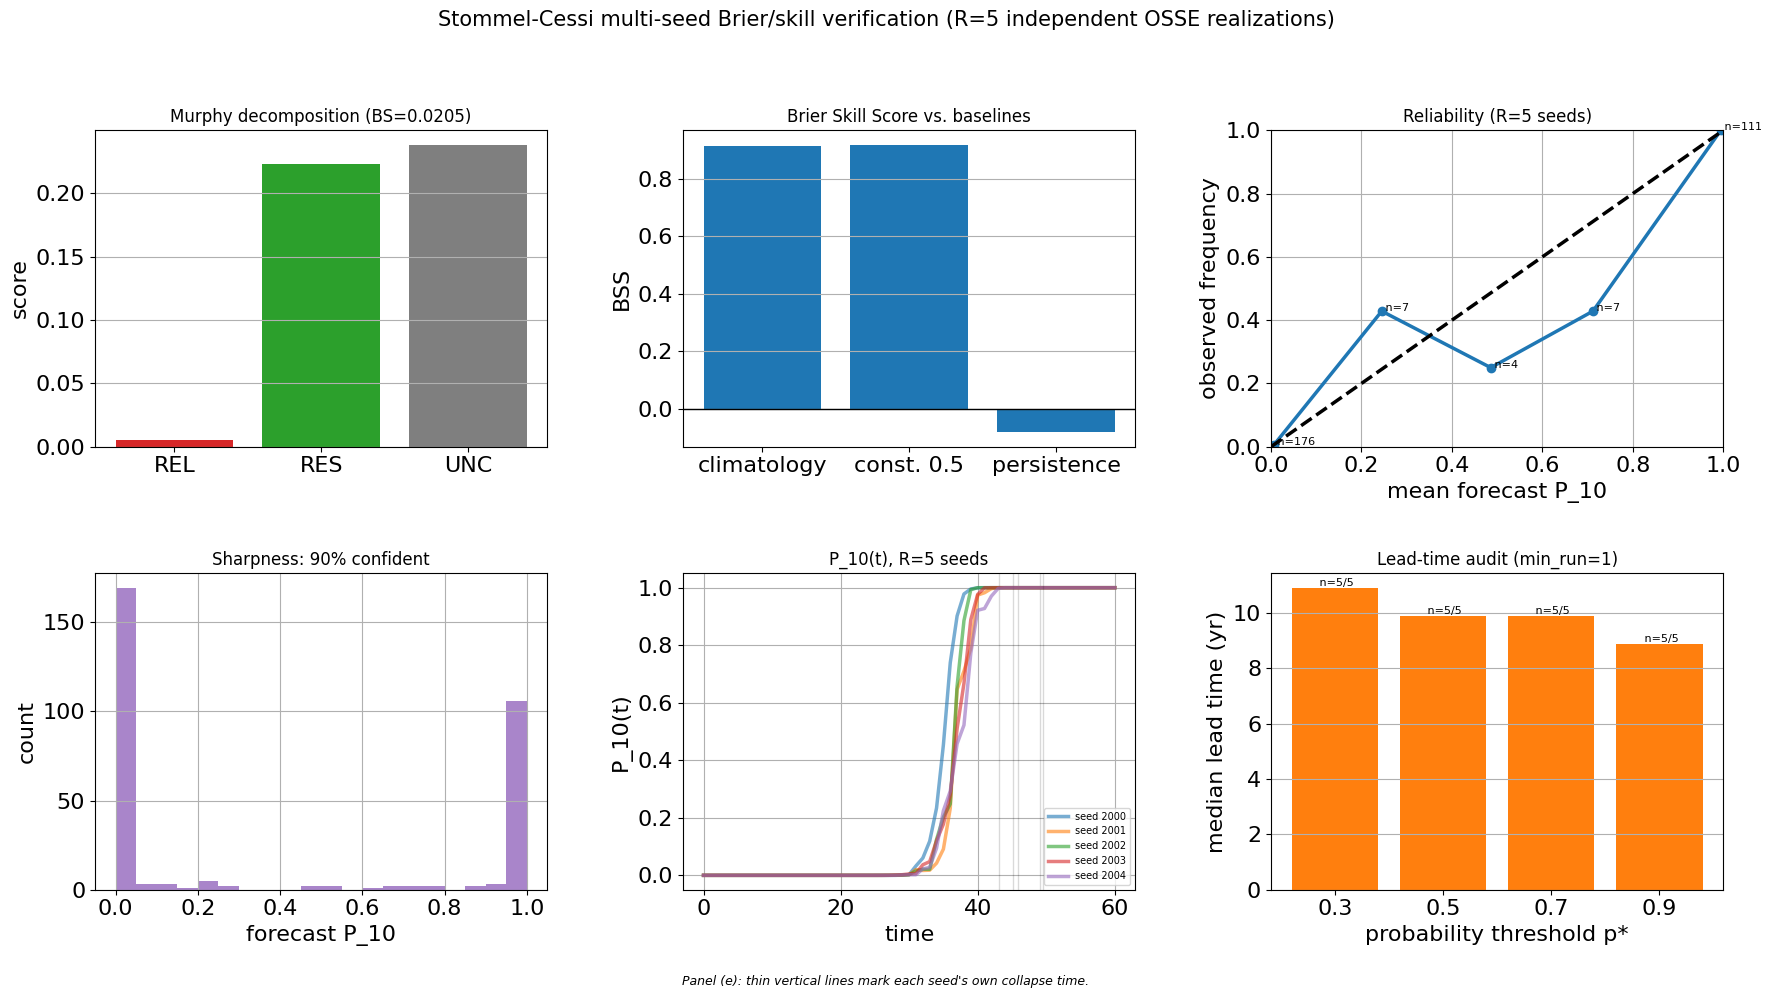

In [ ]:
# =============================================================================
#   FIGURE PRESENTATION: multi-seed Brier/skill verification plot
#
#   Pure re-plotting from already-computed numbers -- no simulation is
#   ever re-run here. Uses `multiseed_out` if it's already in memory (same
#   Colab session as the experiment cell); otherwise falls back to loading
#   the final checkpoint pickle from Drive. Either way this cell is cheap
#   and safe to re-run as many times as you want while tweaking the layout.
#
#   Layout fix vs. the first version: the notebook's global rcParams (set
#   in main()) uses axes.titlesize=16, which is too large for a 2x3 grid
#   at this width and was causing titles to bleed into their neighbors.
#   Fixed here with an explicit smaller title fontsize, a wider figure,
#   more wspace, and the long P_10(t) caption moved out of its subplot
#   title into a figure-level caption instead.
# =============================================================================

import pickle
from pathlib import Path

CHECKPOINT_PKL = Path("/content/drive/MyDrive/Paper/checkpoints/stommel_cessi_multiseed_out.pkl")
OUT_DIR = Path("/content/drive/MyDrive/Paper")


def _build_multiseed_figure(results, murphy, BSS_clim, BSS_half, BSS_persist,
                             audit, P_all, E_all):
    """Build (but don't save) the multi-seed Brier/skill figure."""
    TITLE_FS = 12

    fig6, axs6 = plt.subplots(2, 3, figsize=(18, 10), facecolor="w")

    ax = axs6[0, 0]
    ax.bar(["REL", "RES", "UNC"], [murphy["REL"], murphy["RES"], murphy["UNC"]],
           color=["tab:red", "tab:green", "tab:grey"])
    ax.set_title(f"Murphy decomposition (BS={murphy['BS']:.4f})", fontsize=TITLE_FS)
    ax.set_ylabel("score")
    ax.grid(True, axis="y")

    ax = axs6[0, 1]
    ax.bar(["climatology", "const. 0.5", "persistence"],
           [BSS_clim, BSS_half, BSS_persist], color="tab:blue")
    ax.axhline(0, color="k", linewidth=1)
    ax.set_title("Brier Skill Score vs. baselines", fontsize=TITLE_FS)
    ax.set_ylabel("BSS")
    ax.grid(True, axis="y")

    ax = axs6[0, 2]
    bins = np.linspace(0, 1, 6)
    binMid, obsFreq, binCount = reliability_curve(P_all, E_all, bins)
    ax.plot(binMid, obsFreq, "o-")
    ax.plot([0, 1], [0, 1], "k--")
    for bb in range(len(binMid)):
        if np.isfinite(obsFreq[bb]):
            ax.text(binMid[bb], obsFreq[bb], f" n={binCount[bb]}", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("mean forecast P_10")
    ax.set_ylabel("observed frequency")
    ax.set_title(f"Reliability (R={len(results)} seeds)", fontsize=TITLE_FS)
    ax.grid(True)

    ax = axs6[1, 0]
    ax.hist(P_all, bins=20, range=(0, 1), color="tab:purple", alpha=0.8)
    confident = np.mean((P_all <= 0.05) | (P_all >= 0.95))
    ambivalent = np.mean((P_all >= 0.4) & (P_all <= 0.6))
    ax.set_title(f"Sharpness: {100*confident:.0f}% confident", fontsize=TITLE_FS)
    ax.set_xlabel("forecast P_10")
    ax.set_ylabel("count")
    ax.grid(True)

    ax = axs6[1, 1]
    for r in results:
        valid = r["valid_horizon"] & np.isfinite(r["P10"])
        ax.plot(r["obs_time"][valid], r["P10"][valid], alpha=0.6,
                label=f"seed {r['seed']}")
        if np.isfinite(r["t_collapse"]):
            ax.axvline(r["t_collapse"], color="k", alpha=0.15, linewidth=1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("time")
    ax.set_ylabel("P_10(t)")
    ax.set_title(f"P_10(t), R={len(results)} seeds", fontsize=TITLE_FS)
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True)

    ax = axs6[1, 2]
    p_stars_plot = sorted(set(k[0] for k in audit))
    min_run_plot = 1
    leads_medians = [audit[(p, min_run_plot)]["median_lead"] for p in p_stars_plot]
    n_warned = [audit[(p, min_run_plot)]["n_seeds_with_warning"] for p in p_stars_plot]
    ax.bar([str(p) for p in p_stars_plot], leads_medians, color="tab:orange")
    for i, n in enumerate(n_warned):
        ax.text(i, leads_medians[i], f" n={n}/{len(results)}", ha="center",
                va="bottom", fontsize=8)
    ax.set_xlabel("probability threshold p*")
    ax.set_ylabel("median lead time (yr)")
    ax.set_title(f"Lead-time audit (min_run={min_run_plot})", fontsize=TITLE_FS)
    ax.grid(True, axis="y")

    fig6.suptitle(f"Stommel-Cessi multi-seed Brier/skill verification "
                  f"(R={len(results)} independent OSSE realizations)", fontsize=15)
    fig6.text(0.5, 0.005,
              "Panel (e): thin vertical lines mark each seed's own collapse time.",
              ha="center", fontsize=9, style="italic")

    fig6.tight_layout(rect=[0, 0.02, 1, 0.95])
    fig6.subplots_adjust(hspace=0.4, wspace=0.3)
    return fig6


# ------------------------- LOAD RESULTS (no recompute) ---------------------------
if "multiseed_out" in globals():
    print("Using multiseed_out already in memory -- no reload needed.")
    _cached = multiseed_out
    P_all, E_all = _cached["pooled"]["P"], _cached["pooled"]["E"]
else:
    print(f"multiseed_out not in memory, loading checkpoint: {CHECKPOINT_PKL}")
    with open(CHECKPOINT_PKL, "rb") as f:
        _cached = pickle.load(f)
    # pool_multiseed_results() must already be defined (from the experiment
    # cell above this one) -- it's just array concatenation, not simulation.
    P_all, E_all, _, _ = pool_multiseed_results(_cached["results"])

# ------------------------- BUILD + SAVE ---------------------------
fig6 = _build_multiseed_figure(
    _cached["results"], _cached["murphy"], _cached["BSS_clim"],
    _cached["BSS_half"], _cached["BSS_persist"], _cached["audit"],
    P_all, E_all,
)
out_path = OUT_DIR / "amoc_pf_tams_cessi1994_multiseed_fig06.png"
fig6.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="w")
print(f"Saved fixed figure: {out_path}")
fig6